In [27]:
import pandas as pd

df = pd.read_csv("/content/amazon.csv")
df.head()


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [28]:
df.shape

(1465, 16)

In [29]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [31]:
import numpy as np
import pandas as pd

# ---------- helpers ----------
def clean_currency_to_float(s: pd.Series) -> pd.Series:
    """
    Converts currency-like strings (e.g., '₹1,299', '$1,299', '1,299') -> float
    """
    return (s.astype(str)
              .str.replace(r"[^\d.]", "", regex=True)   # keep digits + dot only
              .replace({"": np.nan, "nan": np.nan})
              .astype(float))

def clean_percent_to_float(s: pd.Series) -> pd.Series:
    """
    Converts percent-like strings (e.g., '62%', '62.5 %') -> float (62.0 / 62.5)
    """
    return (s.astype(str)
              .str.replace("%", "", regex=False)
              .str.replace(r"[^\d.]", "", regex=True)
              .replace({"": np.nan, "nan": np.nan})
              .astype(float))

def clean_rating_to_float(s: pd.Series) -> pd.Series:
    """
    Converts rating strings (e.g., '4.3 out of 5', '4.3') -> float
    """
    extracted = s.astype(str).str.extract(r"(\d+(\.\d+)?)")[0]
    return pd.to_numeric(extracted, errors="coerce")

def clean_count_to_int(s: pd.Series) -> pd.Series:
    """
    Converts count strings (e.g., '1,234', '1234') -> pandas nullable Int64
    """
    cleaned = (s.astype(str)
                 .str.replace(",", "", regex=False)
                 .str.replace(r"[^\d]", "", regex=True)
                 .replace({"": np.nan, "nan": np.nan}))
    return pd.to_numeric(cleaned, errors="coerce").astype("Int64")


In [32]:
# ---------- BEFORE (optional quick check) ----------
print("BEFORE dtypes:\n", df[["discounted_price","actual_price","discount_percentage","rating","rating_count"]].dtypes)


BEFORE dtypes:
 discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
dtype: object


In [33]:
# ---------- conversions ----------
df["discounted_price"] = clean_currency_to_float(df["discounted_price"])
df["actual_price"]     = clean_currency_to_float(df["actual_price"])
df["discount_percentage"] = clean_percent_to_float(df["discount_percentage"])
df["rating"]           = clean_rating_to_float(df["rating"])
df["rating_count"]     = clean_count_to_int(df["rating_count"])


In [34]:
# ---------- sanity checks / validation ----------
# 1) basic dtype check
print("\nAFTER dtypes:\n", df[["discounted_price","actual_price","discount_percentage","rating","rating_count"]].dtypes)

# 2) quick missing values introduced by parsing
print("\nMissing after conversion:\n", df[["discounted_price","actual_price","discount_percentage","rating","rating_count"]].isna().sum())

# 3) guardrails (optional)
print("\nSanity ranges:")
print("Price min/max:", df["discounted_price"].min(), df["discounted_price"].max())
print("Discount% min/max:", df["discount_percentage"].min(), df["discount_percentage"].max())
print("Rating min/max:", df["rating"].min(), df["rating"].max())

# 4) spot-check
df[["product_name","discounted_price","actual_price","discount_percentage","rating","rating_count"]].sample(5, random_state=42)


AFTER dtypes:
 discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count             Int64
dtype: object

Missing after conversion:
 discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
dtype: int64

Sanity ranges:
Price min/max: 39.0 77990.0
Discount% min/max: 0.0 94.0
Rating min/max: 2.0 5.0


,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count
976,Xiaomi Pad 5| Qualcomm Snapdragon 860| 120Hz R...,26999.0,37999.0,29.0,4.6,2886
175,"Skadioo WiFi Adapter for pc | Car Accessories,...",199.0,499.0,60.0,3.7,612
275,LOHAYA Voice Assistant Remote Compatible for A...,399.0,999.0,60.0,3.3,23
548,POPIO Tempered Glass Screen Protector Compatib...,299.0,599.0,50.0,4.3,4674
869,TP-Link Nano AC600 USB Wi-Fi Adapter(Archer T2...,999.0,1599.0,38.0,4.3,12093


In [35]:
import numpy as np
import pandas as pd

# 1) Absolute savings (₹ saved)
df["savings"] = df["actual_price"] - df["discounted_price"]

# 2) Discount fraction (0–1) for easier modeling/plots
df["discount_frac"] = df["discount_percentage"] / 100

# 3) Price bucket (consumer affordability segments)
df["price_bucket"] = pd.qcut(
    df["discounted_price"],
    q=4,
    labels=["Budget", "Mid", "Premium", "Luxury"]
)

# 4) Popularity proxy bucket (based on rating_count)
# (handles missing because rating_count is nullable Int64)
df["rating_count_filled"] = df["rating_count"].fillna(0)

df["popularity_bucket"] = pd.qcut(
    df["rating_count_filled"].rank(method="first"),
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

# Quick check
df[["actual_price","discounted_price","discount_percentage","savings","price_bucket","rating","rating_count","popularity_bucket"]].head()


,actual_price,discounted_price,discount_percentage,savings,price_bucket,rating,rating_count,popularity_bucket
0,1099.0,399.0,64.0,700.0,Mid,4.2,24269,Very High
1,349.0,199.0,43.0,150.0,Budget,4.0,43994,Very High
2,1899.0,199.0,90.0,1700.0,Budget,3.9,7928,High
3,699.0,329.0,53.0,370.0,Mid,4.2,94363,Very High
4,399.0,154.0,61.0,245.0,Budget,4.2,16905,High


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Log transform rating count to reduce skew
df["log_rating_count"] = np.log1p(df["rating_count_filled"])


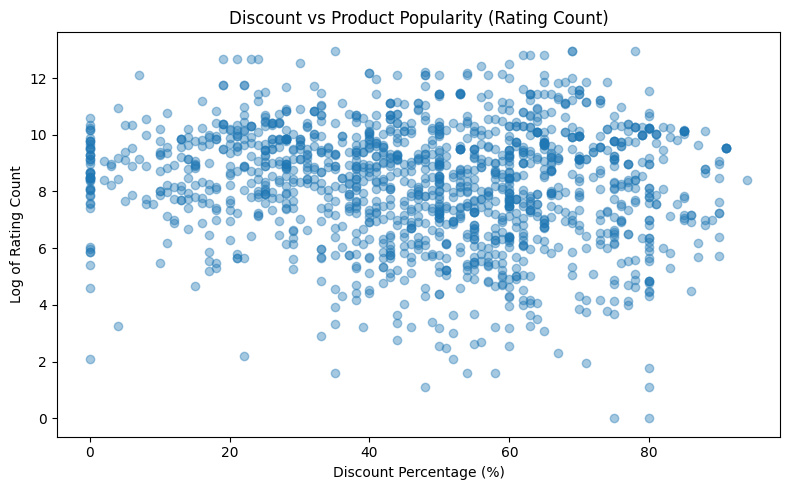

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["discount_percentage"],
    df["log_rating_count"],
    alpha=0.4
)

plt.xlabel("Discount Percentage (%)")
plt.ylabel("Log of Rating Count")
plt.title("Discount vs Product Popularity (Rating Count)")

plt.tight_layout()
plt.show()


In [38]:
import numpy as np

df["log_rating_count"] = np.log1p(df["rating_count"])


In [39]:
category_summary = (
    df.groupby("category")
      .agg(
          avg_discount=("discount_percentage", "mean"),
          avg_popularity=("log_rating_count", "mean"),
          product_count=("product_id", "count")
      )
      .reset_index()
)


In [40]:
category_summary = category_summary[category_summary["product_count"] >= 20]


In [41]:
top_categories = (
    df["category"]
    .value_counts()
    .head(8)
    .index
)

filtered = category_summary[
    category_summary["category"].isin(top_categories)
]


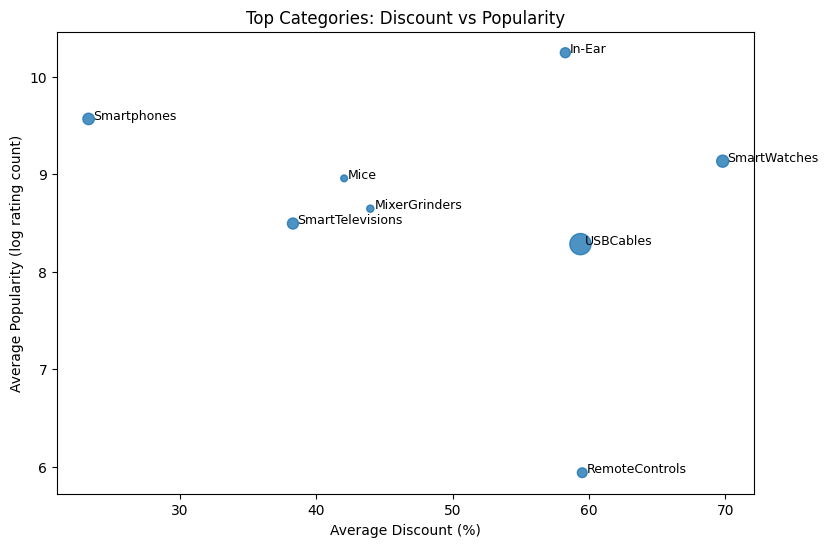

In [42]:
plt.figure(figsize=(9,6))
plt.scatter(
    filtered["avg_discount"],
    filtered["avg_popularity"],
    s=filtered["product_count"],
    alpha=0.8
)

plt.xlabel("Average Discount (%)")
plt.ylabel("Average Popularity (log rating count)")
plt.title("Top Categories: Discount vs Popularity")

for _, row in filtered.iterrows():
    plt.text(
        row["avg_discount"]+0.3,
        row["avg_popularity"],
        row["category"].split("|")[-1],  # shorter label
        fontsize=9
    )

plt.show()


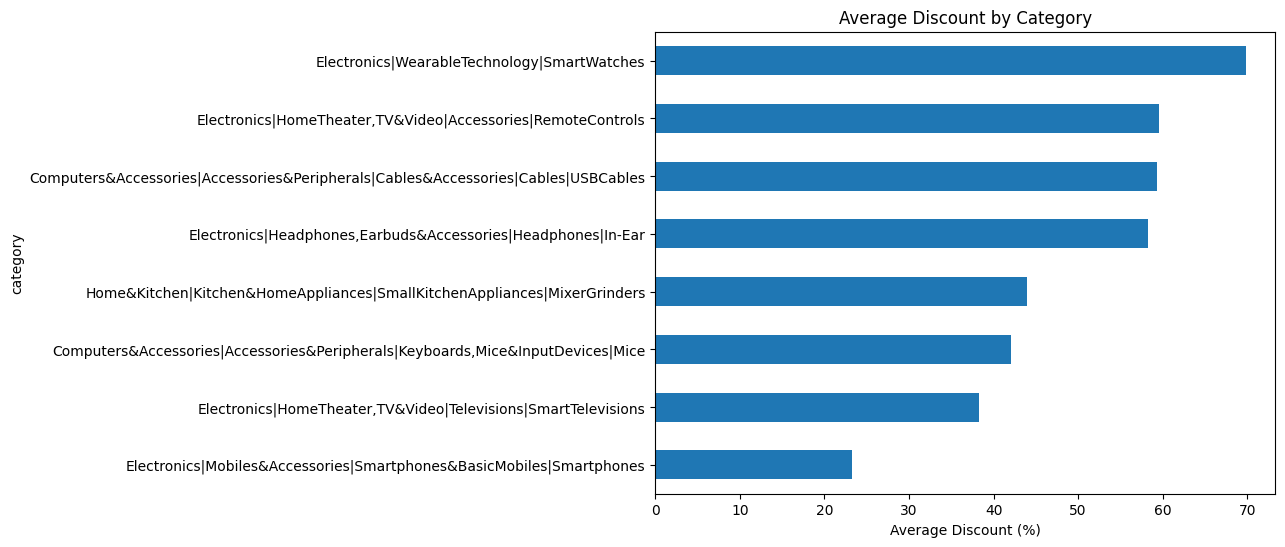

In [43]:
filtered.sort_values("avg_discount").plot(
    x="category",
    y="avg_discount",
    kind="barh",
    figsize=(8,6),
    legend=False,
    title="Average Discount by Category"
)
plt.xlabel("Average Discount (%)")
plt.show()


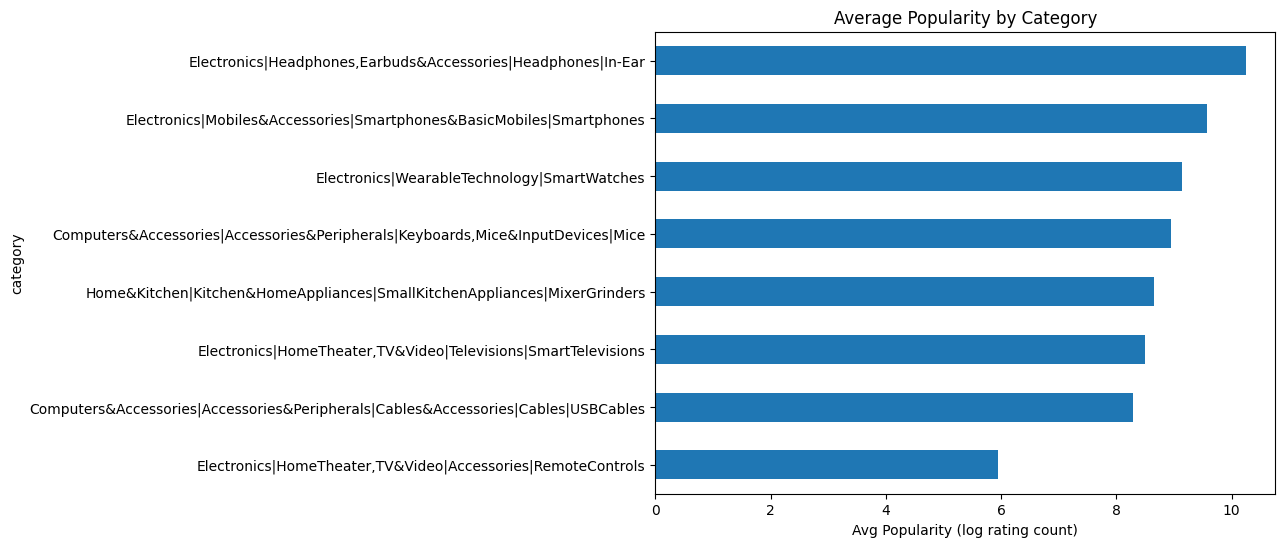

In [44]:
filtered.sort_values("avg_popularity").plot(
    x="category",
    y="avg_popularity",
    kind="barh",
    figsize=(8,6),
    legend=False,
    title="Average Popularity by Category"
)
plt.xlabel("Avg Popularity (log rating count)")
plt.show()


/tmp/ipython-input-4137456821.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_summary.groupby("discount_bucket")["avg_popularity"].mean().plot(


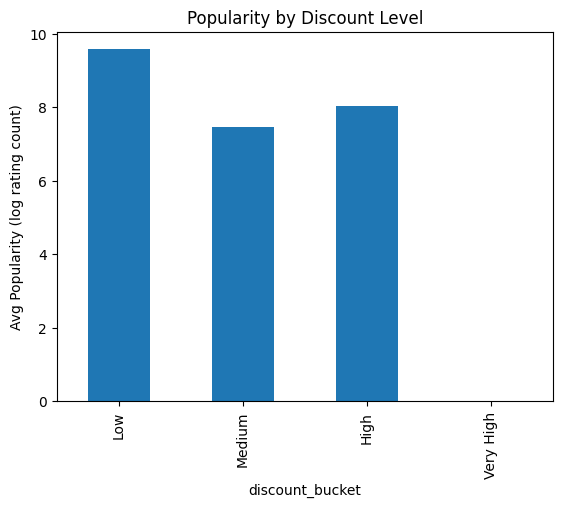

In [45]:
category_summary["discount_bucket"] = pd.cut(
    category_summary["avg_discount"],
    bins=[0,30,50,70,100],
    labels=["Low","Medium","High","Very High"]
)

category_summary.groupby("discount_bucket")["avg_popularity"].mean().plot(
    kind="bar",
    title="Popularity by Discount Level",
    ylabel="Avg Popularity (log rating count)"
)
plt.show()


In [46]:
# Over-Discounted but Low-Popularity Products

# thresholds
high_discount_thresh = df["discount_percentage"].quantile(0.75)
low_popularity_thresh = df["rating_count_filled"].quantile(0.25)


In [47]:
# Filetering the risky products

over_discounted_low_popularity = df[
    (df["discount_percentage"] >= high_discount_thresh) &
    (df["rating_count_filled"] <= low_popularity_thresh)
]


In [48]:
# inspecting the worst offenders

over_discounted_low_popularity[
    ["product_name", "category", "discount_percentage", "savings", "rating", "rating_count"]
].sort_values("discount_percentage", ascending=False).head(10)


,product_name,category,discount_percentage,savings,rating,rating_count
920,"Silicone Rubber Earbuds Tips, Eartips, Earpads...","Electronics|Headphones,Earbuds&Accessories|Ear...",90.0,900.0,3.8,594
557,LAPSTER 12pcs Spiral Cable Protectors for Char...,Electronics|Mobiles&Accessories|MobileAccessor...,90.0,900.0,4.4,305
246,pTron Solero M241 2.4A Micro USB Data & Chargi...,Computers&Accessories|Accessories&Peripherals|...,89.0,711.0,3.9,1075
227,Rts™ High Speed 3D Full HD 1080p Support (10 M...,"Electronics|HomeTheater,TV&Video|Accessories|C...",88.0,4401.0,4.2,910
285,pTron Solero T241 2.4A Type-C Data & Charging ...,Computers&Accessories|Accessories&Peripherals|...,88.0,701.0,3.9,1075
248,Croma 3A Fast charge 1m Type-C to All Type-C P...,Computers&Accessories|Accessories&Peripherals|...,87.0,871.0,3.9,295
653,STRIFF Mpad Mouse Mat 230X190X3mm Gaming Mouse...,Computers&Accessories|Accessories&Peripherals|...,87.0,870.0,4.2,491
545,SHREENOVA ID116 Plus Bluetooth Fitness Smart W...,Electronics|WearableTechnology|SmartWatches,86.0,1718.0,2.8,87
1376,"Macmillan Aquafresh 5 Micron PS-05 10"" in PP S...",Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,86.0,1284.0,3.9,1004
741,Amazon Basics Multipurpose Foldable Laptop Tab...,Computers&Accessories|Accessories&Peripherals|...,85.0,3400.0,3.9,1087


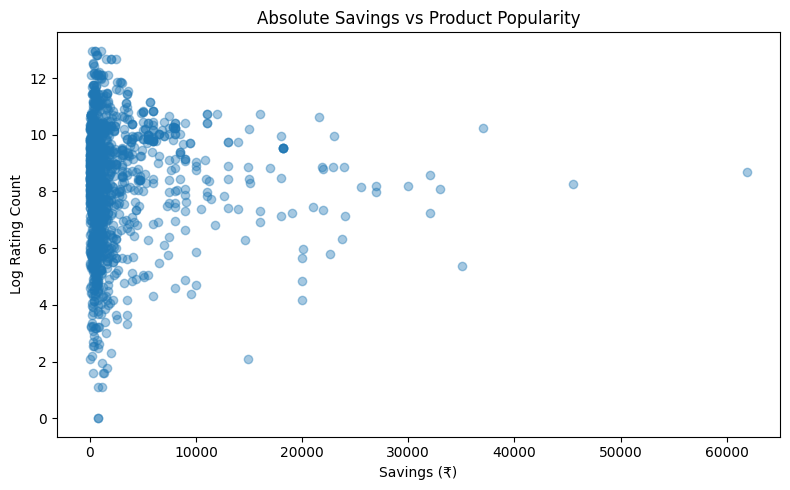

In [49]:
# Savings VS Popularity

plt.figure(figsize=(8,5))

plt.scatter(
    df["savings"],
    np.log1p(df["rating_count_filled"]),
    alpha=0.4
)

plt.xlabel("Savings (₹)")
plt.ylabel("Log Rating Count")
plt.title("Absolute Savings vs Product Popularity")
plt.tight_layout()
plt.show()


In [50]:
# Price Bucket × Rating

price_rating_summary = (
    df.groupby("price_bucket")
      .agg(
          avg_rating=("rating", "mean"),
          avg_popularity=("rating_count_filled", "mean"),
          product_count=("product_id", "count")
      )
      .reset_index()
)


/tmp/ipython-input-4018865925.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_bucket")


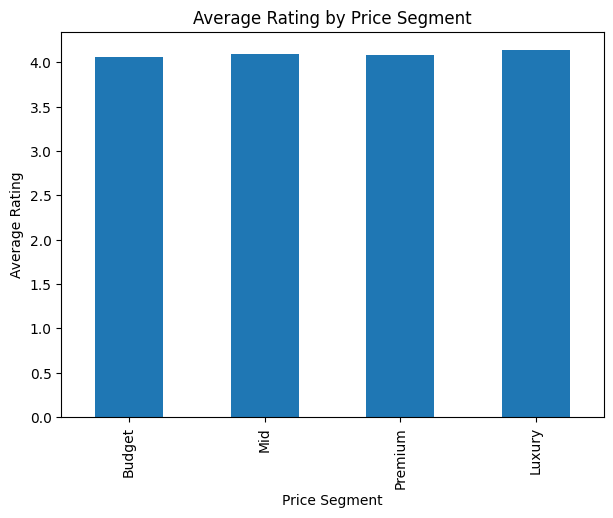

In [51]:
price_rating_summary.plot(
    x="price_bucket",
    y="avg_rating",
    kind="bar",
    figsize=(7,5),
    legend=False,
    title="Average Rating by Price Segment"
)

plt.xlabel("Price Segment")
plt.ylabel("Average Rating")
plt.show()
